<a href="https://colab.research.google.com/github/Sanraj-Lachhiramka/From-Embeddings-to-Insights-Text-Clustering-and-Topic-Modeling-with-BERTopic/blob/main/From_Embeddings_to_Insights_Text_Clustering_and_Topic_Modeling_with%C2%A0BERTopic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Text Clustering and Topic Modeling on ArXiv Research Papers

This notebook demonstrates a complete NLP pipeline for analyzing scholarly articles from ArXiv (specifically the Computation and Language section). We utilize modern techniques including transformer-based embeddings, UMAP for dimensionality reduction, HDBSCAN for clustering, and BERTopic for sophisticated topic discovery.

### Data Acquisition
We load the dataset from Hugging Face and extract the titles and abstracts which serve as our primary data for analysis.

In [ ]:
# Load dataset
from datasets import load_dataset
dataset=load_dataset("maartengr/arxiv_nlp")["train"]

#Extract Metadata
abstracts = dataset["Abstracts"]
titles = dataset["Titles"]

print(abstracts[0])
print(titles[0])

  In this paper Arabic was investigated from the speech recognition problem
point of view. We propose a novel approach to build an Arabic Automated Speech
Recognition System (ASR). This system is based on the open source CMU Sphinx-4,
from the Carnegie Mellon University. CMU Sphinx is a large-vocabulary;
speaker-independent, continuous speech recognition system based on discrete
Hidden Markov Models (HMMs). We build a model using utilities from the
OpenSource CMU Sphinx. We will demonstrate the possible adaptability of this
system to Arabic voice recognition.

Introduction to Arabic Speech Recognition Using CMUSphinx System


## A Common Pipeline for Text Clustering

### 1. Document Embeddings
Using the `sentence-transformers` library, we convert raw text into high-dimensional vector representations using the `gte-small` model.

In [ ]:
from sentence_transformers import SentenceTransformer

# Create an embeding for each abstract
embedding_model=SentenceTransformer("thenlper/gte-small")
embeddings=embedding_model.encode(abstracts,show_progress_bar=True)

#Check the dimensions of the resulting embeddings
print("The shape of embeddings:",embeddings.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

The shape of embeddings: (44949, 384)


### 2. Dimensionality Reduction
High-dimensional embeddings are difficult to cluster directly due to the 'curse of dimensionality'. We use UMAP to project our 384-dimension embeddings into a 5D space for clustering, and later a 2D space for visualization.

In [ ]:
from umap import UMAP #  Uniform Manifold Approximation and Projection

# Reduce the input embedding from 384 dimensions to 5 dimensions
umap_model=UMAP(n_components=5, # n_components parameter to decide the shape of the lower-dimensional space
                min_dist=0.0, # minimum distance between embedded points. We are setting this to 0 as that generally results in tighter clusters
                metric='cosine', # metric to 'cosine' as Euclidean-based methods have issues dealing with high-dimensional data
                random_state=42 # make the results reproducible across sessions but will disable parallelism and therefore slow down training
                )

reduced_embeddings=umap_model.fit_transform(embeddings)

### 3. Density-Based Clustering
We apply HDBSCAN to identify natural clusters within the reduced embeddings. Unlike K-Means, HDBSCAN doesn't require us to specify the number of clusters in advance and can identify noise (outliers).

In [ ]:
from hdbscan import HDBSCAN

#Fit the model and extract the clusters
hdbscan_model=HDBSCAN(min_cluster_size=50, # Each cluster must have at least 50 points. Smaller groups will be treated as noise
                      metric="euclidean", # Distance between points is measured using standard Euclidean distance
                      cluster_selection_method="eom" # “Excess of Mass” — a method HDBSCAN uses to decide which clusters are stable and meaningful
                      ).fit(reduced_embeddings)

clusters=hdbscan_model.labels_ # labels_ assigns a cluster ID to each data point
# Cluster IDs are integers: 0, 1, 2, ...
# Noise points are labeled as -1

# Counting clusters
len(set(clusters))


159

### 5. Cluster Visualization
Visualizing the clusters in a 2D plane helps validate the quality of our groupings. We distinguish between assigned clusters and noise points (outliers).

In [ ]:
import numpy as np

# Print first 3 documents in cluster 0
cluster=0

for index in np.where(clusters == cluster)[0][:3]:
    # clusters is your array of labels from HDBSCAN.
    # clusters == cluster creates a boolean mask (True for points in cluster 0).
    # np.where(...) returns the indices of those points.
    # [0] extracts the actual index array


    print(abstracts[int(index)][:300] + "...\n")
    # abstracts[index]: gets the original text (probably a document or paper abstract)
    # [:300]: shows only the first 300 characters
    # "...": indicates truncation
    # \n: adds spacing between outputs

  This works aims to design a statistical machine translation from English text
to American Sign Language (ASL). The system is based on Moses tool with some
modifications and the results are synthesized through a 3D avatar for
interpretation. First, we translate the input text to gloss, a written fo...

  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonological and phonetic aspects, and gesture studies for
recognition and synthesis purposes. This paper focuses on the imbrication of
motion and meaning for the analysis, synthesis and evaluation of sign lang...

  Modern computational linguistic software cannot produce important aspects of
sign language translation. Using some researches we deduce that the majority of
automatic sign language translation systems ignore many aspects when they
generate animation; therefore the interpretation lost the truth inf...



We can take this one step further and attempt to visualize our results instead
of going through all documents manually. To do so, we will need to reduce
our document embeddings to two dimensions, as that allows us to plot the
documents on an x/y plane:

In [ ]:
import pandas as pd
# Reduce 384-dimensional embeddings to two dimensions for easier  visualization
reduced_embeddings = UMAP(
    n_components=2,
    min_dist=0.0,
    metric="cosine",
random_state=42
).fit_transform(embeddings)

# Create dataframe
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]
# You store the 2D coordinates in columns x and y.
# titles likely labels each data point (e.g., document names).
# clusters contains cluster IDs.
# Clusters are converted to strings for easier handling/plotting.

# Select outliers and non-outliers (clusters)
to_plot = df.loc[df.cluster != "-1", :]
outliers = df.loc[df.cluster == "-1", :]
# In many clustering algorithms, -1 represents outliers/noise.
# to_plot = all points that belong to real clusters.
# outliers = points that didn’t fit into any cluster.

(np.float64(-9.041299676895141),
 np.float64(11.615294313430786),
 np.float64(-7.6163016080856325),
 np.float64(11.084579062461852))

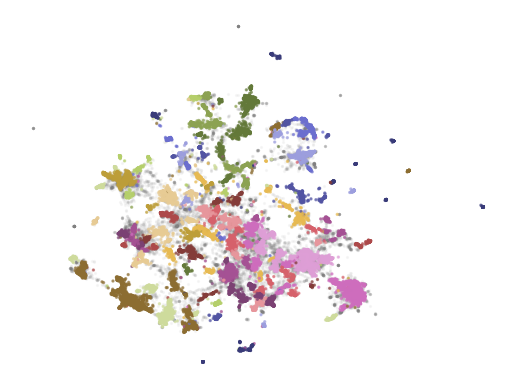

In [ ]:
import matplotlib.pyplot as plt
# Plot outliers and non-outliers separately
plt.scatter(outliers.x, outliers.y, alpha=0.05, s=2,
c="grey")
# Plots points labeled as -1 (noise from clustering)
# alpha=0.05 → very transparent, so they don’t dominate the plot
# s=2 → tiny dots (good for large datasets)
# c="grey" → neutral color

plt.scatter(
to_plot.x, to_plot.y,
c=to_plot.cluster.astype(int),
alpha=0.6, s=2, cmap="tab20b"
)
# Plots only points that belong to clusters
# c=to_plot.cluster.astype(int) → assigns a color based on cluster ID
# cmap="tab20b" → a colormap with many distinct colors (good for multiple clusters)
# alpha=0.6 → more visible than outliers
# s=2 → still small dots

plt.axis("off")

### 5. Topic Modeling with BERTopic
We leverage BERTopic to extract interpretable topics from our clusters. This combined approach allows us to see not just *where* documents group together, but *what* they are actually about using class-based TF-IDF.

In [ ]:
!pip install bertopic

In [ ]:
from bertopic import BERTopic

# Train our model with our previously defined models
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True # Prints progress logs while training
).fit(abstracts, embeddings)
# fitting (training) the model on your data:
# abstracts → list of text documents (e.g., research paper abstracts)
# embeddings → precomputed vector representations of those texts


# What happens in BERTopic?
# Takes your embeddings
# Reduces dimensions using UMAP
# Clusters them using HDBSCAN
# Extracts keywords for each cluster (topic)

2026-05-01 20:21:18,423 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-01 20:22:53,028 - BERTopic - Dimensionality - Completed ✓
2026-05-01 20:22:53,030 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-01 20:22:55,586 - BERTopic - Cluster - Completed ✓
2026-05-01 20:22:55,603 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-01 20:23:00,162 - BERTopic - Representation - Completed ✓


In [ ]:
# get_topic_info() returns a summary table of all discovered topics in your BERTopic model
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,15538,-1_the_of_and_to,"[the, of, and, to, in, we, for, that, language...",[ Learning to construct text representations ...
1,0,1587,0_speech_asr_recognition_end,"[speech, asr, recognition, end, acoustic, wer,...",[ Recent advances in text-to-speech (TTS) led...
2,1,1479,1_medical_clinical_biomedical_patient,"[medical, clinical, biomedical, patient, healt...",[ A common practice in the medical industry i...
3,2,1069,2_translation_nmt_machine_bleu,"[translation, nmt, machine, bleu, neural, engl...",[ The quality of machine translation is rapid...
4,3,837,3_hate_offensive_speech_detection,"[hate, offensive, speech, detection, toxic, so...",[ With growing role of social media in shapin...
...,...,...,...,...,...
154,153,54,153_counseling_mental_therapy_health,"[counseling, mental, therapy, health, psychoth...",[ Mental health care poses an increasingly se...
155,154,52,154_backdoor_attacks_attack_triggers,"[backdoor, attacks, attack, triggers, poisoned...",[ Deep neural networks (DNNs) and natural lan...
156,155,52,155_gans_gan_adversarial_generation,"[gans, gan, adversarial, generation, generativ...",[ Text generation is of particular interest i...
157,156,51,156_temporal_events_event_timeml,"[temporal, events, event, timeml, relations, r...",[ Temporal relation extraction models have th...


In [ ]:
# Retrieves the top keywords for a specific topic (Topic 0) from your BERTopic model
topic_model.get_topic(0)

[('speech', np.float64(0.028533409123771385)),
 ('asr', np.float64(0.019138833922540077)),
 ('recognition', np.float64(0.013909133719155576)),
 ('end', np.float64(0.010621429434304063)),
 ('acoustic', np.float64(0.010460956236705904)),
 ('wer', np.float64(0.007447408821110592)),
 ('speaker', np.float64(0.0073356609562662605)),
 ('error', np.float64(0.006711808807312123)),
 ('ctc', np.float64(0.006453412080461576)),
 ('training', np.float64(0.0064466744613668105))]

In [ ]:
# find_topics() function to search for specific topics based on a search term
topic_model.find_topics("topic modelling")

# It typically returns two lists:
# First list → Topic IDs
# Second list → Similarity scores (higher = more similar)

([25, -1, 46, 1, 39],
 [np.float64(0.9467714462806254),
  np.float64(0.9066330535669577),
  np.float64(0.9048234453858618),
  np.float64(0.9036587205392311),
  np.float64(0.8992127526007326)])

In [ ]:
topic_model.get_topic(25)

[('topic', np.float64(0.06831864242630711)),
 ('topics', np.float64(0.035413101051171125)),
 ('lda', np.float64(0.016777588269087314)),
 ('latent', np.float64(0.013417677887956022)),
 ('documents', np.float64(0.013225652438289246)),
 ('document', np.float64(0.01266020511629316)),
 ('modeling', np.float64(0.011969201882545685)),
 ('dirichlet', np.float64(0.010026181837130724)),
 ('word', np.float64(0.008723303654661967)),
 ('allocation', np.float64(0.00783607294397915))]

In [ ]:
# Get the topic assigned to that document
topic_model.topics_[titles.index("BERTopic: Neural topic modeling with a class-based TF-IDF procedure")]

25

In [ ]:
# Visualize topics and documents
titles = list(dataset["Titles"])

fig = topic_model.visualize_documents(
    titles, # Labels shown when hovering over points
    reduced_embeddings=reduced_embeddings, # 2D coordinates of documents
    width=1200,
    hide_annotations=True # Hides text labels directly on points
)
# It plots each document in a 2D space, where:
# Each point = one document (title)
# Distance = semantic similarity
# Clusters = topics discovered by BERTopic

# Increase fonts of legend for easier visualization
fig.update_layout(font=dict(size=16))


In [ ]:
# Visualize barchart with ranked keywords
topic_model.visualize_barchart()
# Visualize relationships between topics
topic_model.visualize_heatmap(n_clusters=30)
# Visualize the potential hierarchical structure of topics
topic_model.visualize_hierarchy()

### 6. Refining Topic Representations
To improve the quality of the generated topics, we experiment with different representation models like **KeyBERTInspired** (to focus on keywords) and **Maximal Marginal Relevance** (to ensure keyword diversity).

In [ ]:
# Save original representations
from copy import deepcopy
original_topics = deepcopy(topic_model.topic_representations_)

In [ ]:
def topic_differences(model, original_topics, nr_topics=5):
  """Show the differences in topic representations between two models """

  # Creates an empty table to store results
  df = pd.DataFrame(columns=["Topic", "Original", "Updated"])

  # Loops through topic IDs: 0, 1, 2, ..., nr_topics-1
  for topic in range(nr_topics):

    # Extract top 5 words per topic per mode
    og_words = " | ".join(list(zip(*original_topics[topic]))[0][:5])
    new_words = " | ".join(list(zip(*model.get_topic(topic)))[0][:5])

    # Adds a new row for each topic and stores the results
    df.loc[len(df)] = [topic, og_words, new_words]

  return df

#### **KeyBERTInspired**

In [ ]:
from bertopic.representation import KeyBERTInspired

# Update our topic representations using KeyBERTInspired
representation_model = KeyBERTInspired()

# Recompute topic representations for the already learned topics using this new method
topic_model.update_topics(abstracts,
representation_model=representation_model)

# topic_model.update_topics(...)
  # does NOT change clustering
  # only improves interpretability of existing topics

In [ ]:
# Show topic differences
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,speech | language | phonetic | translation | t...
1,1,medical | clinical | biomedical | patient | he...,clinical | nlp | ehr | medicine | corpus
2,2,translation | nmt | machine | bleu | neural,translation | translations | multilingual | tr...
3,3,hate | offensive | speech | detection | toxic,hate | hateful | language | offensive | cyberb...
4,4,relation | extraction | re | relations | entity,relation | relations | relational | sentences ...


#### **Maximal marginal relevance**

In [ ]:
from bertopic.representation import MaximalMarginalRelevance

# Update our topic representations to MaximalMarginalRelevance
representation_model = MaximalMarginalRelevance(diversity=0.2) # Diversity = how much you want topic keywords to avoid repeating the same idea

topic_model.update_topics(abstracts,
representation_model=representation_model)

In [ ]:
# Show topic differences
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,speech | asr | wer | ctc | training
1,1,medical | clinical | biomedical | patient | he...,medical | clinical | biomedical | patient | he...
2,2,translation | nmt | machine | bleu | neural,translation | nmt | bleu | neural | parallel
3,3,hate | offensive | speech | detection | toxic,hate | offensive | toxic | abusive | hateful
4,4,relation | extraction | re | relations | entity,relation | extraction | relations | entity | e...


## 7. Generative AI Refinement
While c-TF-IDF provides accurate keywords, we can leverage Large Language Models (LLMs) to generate natural, descriptive labels. We demonstrate three approaches:
1. **Local Generation**: Using Flan-T5 for on-device processing.
2. **Commercial API (OpenAI)**: Leveraging GPT models for high-quality labels.


In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from bertopic.representation import BaseRepresentation
import torch
import pandas as pd

# Load model and tokenizer
model_id = "google/flan-t5-small"
model = AutoModelForSeq2SeqLM.from_pretrained(model_id)
tokenizer = AutoTokenizer.from_pretrained(model_id)

class FlanRepresentation(BaseRepresentation):
    def __init__(self, model, tokenizer, prompt):
        # Stores:
          # the model
          # tokenizer
          # prompt template
        self.model = model
        self.tokenizer = tokenizer
        self.prompt = prompt
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model.to(self.device)

    def extract_topics(self, topic_model, documents, c_tf_idf, topics):
        # Extract keywords for each topic
        repr_topics = {topic: [word for word, _ in topic_model.get_topic(topic)] for topic in topics}

        updated_topics = {}
        for topic, keywords in repr_topics.items():

            # Create prompt
            prompt_text = self.prompt.replace("[KEYWORDS]", ", ".join(keywords[:10]))

            inputs = self.tokenizer(prompt_text, return_tensors="pt").to(self.device)
            with torch.no_grad():
                outputs = self.model.generate(**inputs, max_new_tokens=50)

            # Converts output tokens back into readable text
            label = self.tokenizer.decode(outputs[0], skip_special_tokens=True)

            # BERTopic expects a list of (word, score) tuples for representations
            # We provide the generated label as the primary representation
            updated_topics[topic] = [(label, 1.0)] + topic_model.get_topic(topic)[:9]

        return updated_topics

# Refined prompt
prompt = """I have a topic with keywords: '[KEYWORDS]'. Based on these, what is this topic about?"""

# Initialize our custom representation model
representation_model = FlanRepresentation(model, tokenizer, prompt)

# Update topics
topic_model.update_topics(abstracts, representation_model=representation_model)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [ ]:
# Show topic differences
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,Science/Tech | | | |
1,1,medical | clinical | biomedical | patient | he...,Science/Tech | | | |
2,2,translation | nmt | machine | bleu | neural,Science/Tech | | | |
3,3,hate | offensive | speech | detection | toxic,Science/Tech | | | |
4,4,relation | extraction | re | relations | entity,Science/Tech | | | |


In [ ]:
import openai
from bertopic.representation import OpenAI
prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: [KEYWORDS]
Based on the information above, extract a short topic label in
the following format:
topic: <short topic label>
"""
# Update our topic representations using GPT-3.5
client = openai.OpenAI(api_key="your_api_key")
representation_model = OpenAI(
    client, model="gpt-3.5-turbo", exponential_backoff=True, chat=True, prompt=prompt)
topic_model.update_topics(abstracts,
representation_model=representation_model)

  0%|          | 0/159 [00:00<?, ?it/s]

In [ ]:
# Show topic differences
topic_differences(topic_model, original_topics)

In [ ]:
# Visualize topics and documents
fig = topic_model.visualize_document_datamap(
    titles,
    topics=list(range(20)),
    reduced_embeddings=reduced_embeddings,
    width=1200,
    label_font_size=11,
    label_wrap_width=20,
    use_medoids=True,
)
